FOCUSED TRADITIONAL 'WHAT-IS' ANALYSIS FOR POE DATA
Analyzed: 32 observations, 22 satisfaction variables

TRADITIONAL 'WHAT-IS' METHODS ANALYSIS

1. CORRELATION ANALYSIS
-------------------------
• Strong correlations (|r| > 0.5): 80
• Moderate correlations (0.3 < |r| ≤ 0.5): 88
• Average correlation strength: 0.426

Top 5 correlation clusters:
  1. Views at workspace ↔ Outdoor visibility: r = 0.954
  2. Furnishings comfort ↔ Furnishings adjustability: r = 0.952
  3. Creativity support ↔ Focus support: r = 0.906
  4. Views throughout office ↔ Views at workspace: r = 0.903
  5. Views throughout office ↔ Outdoor visibility: r = 0.862

2. SIGNIFICANCE TESTING
-------------------------
• Variables significantly different from neutral (p < 0.05): 12/22
• Largest deviation from neutral: 1.67

Top 5 deviations from neutral satisfaction:
  1. Office maintenance: 2.53 (below neutral) ***
  2. Ease of interaction: 2.59 (below neutral) ***
  3. Collaboration support: 2.62 (below neutral) ***
  4.

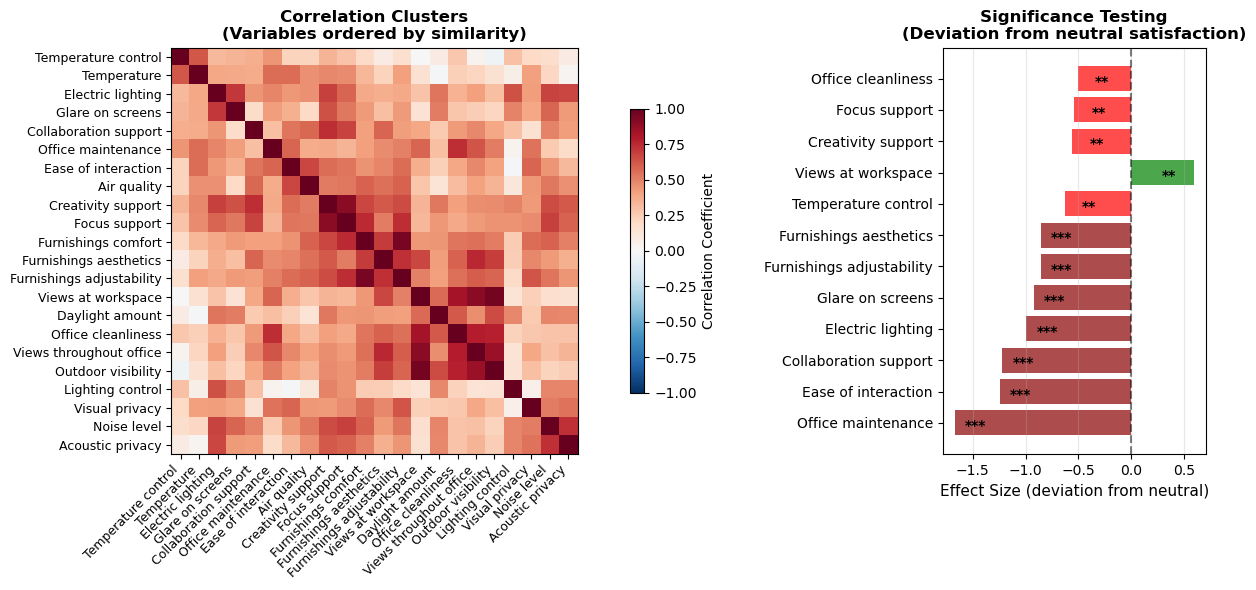


TRADITIONAL METHOD LIMITATIONS ANALYSIS

Dataset: 32 observations, 22 variables

What Traditional Methods Reveal:
• Correlation analysis identifies 80 strong variable clusters
• Significance testing shows 12 variables deviate from neutral
• Strongest correlation: 0.954 between related factors
• Largest dissatisfaction: Office maintenance (effect = -1.67)

ANALYSIS COMPLETE - Results support 'what-is' vs 'what-if' distinction


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('default')
sns.set_palette("husl")

def load_and_prepare_data():
    """Load and prepare the POE validation dataset"""
    # Load data
    df = pd.read_csv('validataion.csv')
    
    # Define satisfaction variables
    sat_variables = [
        "clean_sat_2", "light_sat_2", "furnish_sat_3", "amenities_sat_5", "amenities_sat_4",
        "thermal_sat_2", "clean_sat_1", "iaq_sat_1", "acoustic_sat_1", "layout_sat_3",
        "acoustic_sat_2", "thermal_sat_1", "light_sat_4", "light_sat_1", "light_sat_3",
        "amenities_sat_3", "support_sat_2", "support_sat_1", "layout_sat_2", "furnish_sat_1",
        "furnish_sat_2", "support_sat_3"
    ]
    
    # Node labels mapping
    node_labels = {
        'light_sat_3': 'Glare on screens',
        'support_sat_3': 'Collaboration support',
        'support_sat_2': 'Creativity support',
        'support_sat_1': 'Focus support',
        'furnish_sat_1': 'Furnishings comfort',
        'furnish_sat_2': 'Furnishings adjustability',
        'iaq_sat_1': 'Air quality',
        'acoustic_sat_1': 'Noise level',
        'acoustic_sat_2': 'Acoustic privacy',
        'layout_sat_2': 'Visual privacy',
        'layout_sat_3': 'Ease of interaction',
        'thermal_sat_1': 'Temperature',
        'light_sat_1': 'Electric lighting',
        'light_sat_4': 'Lighting control',
        'thermal_sat_2': 'Temperature control',
        'furnish_sat_3': 'Furnishings aesthetics',
        'amenities_sat_5': 'Views throughout office',
        'amenities_sat_4': 'Views at workspace',
        'clean_sat_1': 'Office cleanliness',
        'amenities_sat_3': 'Outdoor visibility',
        'light_sat_2': 'Daylight amount',
        'clean_sat_2': 'Office maintenance'
    }
    
    # Filter and clean data
    df_analysis = df[sat_variables].copy()
    df_analysis = df_analysis.dropna()
    df_analysis = df_analysis.rename(columns=node_labels)
    
    return df_analysis

def traditional_correlation_analysis(df):
    """Perform correlation analysis"""
    print("TRADITIONAL 'WHAT-IS' METHODS ANALYSIS")
    print("="*45)
    print("\n1. CORRELATION ANALYSIS")
    print("-" * 25)
    
    # Calculate correlation matrix
    corr_matrix = df.corr()
    
    # Find strongest correlations
    corr_pairs = []
    for i in range(len(corr_matrix.columns)):
        for j in range(i+1, len(corr_matrix.columns)):
            corr_pairs.append((
                corr_matrix.columns[i], 
                corr_matrix.columns[j], 
                corr_matrix.iloc[i,j]
            ))
    
    corr_pairs.sort(key=lambda x: abs(x[2]), reverse=True)
    
    # Identify correlation clusters
    strong_corr = len([x for x in corr_pairs if abs(x[2]) > 0.5])
    moderate_corr = len([x for x in corr_pairs if 0.3 < abs(x[2]) <= 0.5])
    
    print(f"• Strong correlations (|r| > 0.5): {strong_corr}")
    print(f"• Moderate correlations (0.3 < |r| ≤ 0.5): {moderate_corr}")
    print(f"• Average correlation strength: {np.abs(corr_matrix.values[np.triu_indices_from(corr_matrix.values, k=1)]).mean():.3f}")
    
    print(f"\nTop 5 correlation clusters:")
    for i, (var1, var2, corr) in enumerate(corr_pairs[:5]):
        print(f"  {i+1}. {var1} ↔ {var2}: r = {corr:.3f}")
    
    return corr_matrix, corr_pairs

def traditional_significance_analysis(df):
    """Perform significance testing"""
    print(f"\n2. SIGNIFICANCE TESTING")
    print("-" * 25)
    
    # Test each variable against neutral (4.0)
    sig_results = {}
    for col in df.columns:
        data = df[col].dropna()
        if len(data) > 0:
            t_stat, p_value = stats.ttest_1samp(data, 4.0)
            effect_size = (data.mean() - 4.0) / data.std() if data.std() > 0 else 0
            
            sig_results[col] = {
                'mean': data.mean(),
                't_stat': t_stat,
                'p_value': p_value,
                'effect_size': effect_size,
                'significant': p_value < 0.05
            }
    
    # Sort by deviation from neutral
    sorted_by_effect = sorted(sig_results.items(), key=lambda x: abs(x[1]['effect_size']), reverse=True)
    
    significant_count = sum(1 for _, result in sig_results.items() if result['significant'])
    
    print(f"• Variables significantly different from neutral (p < 0.05): {significant_count}/{len(sig_results)}")
    print(f"• Largest deviation from neutral: {abs(sorted_by_effect[0][1]['effect_size']):.2f}")
    
    print(f"\nTop 5 deviations from neutral satisfaction:")
    for i, (var, result) in enumerate(sorted_by_effect[:5]):
        direction = "below" if result['mean'] < 4.0 else "above"
        sig_mark = "***" if result['p_value'] < 0.001 else "**" if result['p_value'] < 0.01 else "*" if result['p_value'] < 0.05 else ""
        print(f"  {i+1}. {var}: {result['mean']:.2f} ({direction} neutral) {sig_mark}")
    
    return sorted_by_effect

def create_focused_visualization(df, corr_matrix, corr_pairs, sig_results):
    """Create focused visualization of traditional methods"""
    
    fig, axes = plt.subplots(1, 2, figsize=(15, 6), gridspec_kw={'width_ratios': [8, 2]})
    
    
    # 1. Correlation Heatmap showing clusters
    ax1 = axes[0]
    
    # Use hierarchical clustering to order variables by similarity
    from scipy.cluster.hierarchy import linkage, dendrogram, leaves_list
    linkage_matrix = linkage(df.T, method='ward')
    dendro_order = leaves_list(linkage_matrix)
    
    # Reorder correlation matrix
    ordered_vars = [df.columns[i] for i in dendro_order]
    corr_ordered = corr_matrix.loc[ordered_vars, ordered_vars]
    
    # Create heatmap
    mask = np.triu(np.ones_like(corr_ordered, dtype=bool))
    im = ax1.imshow(corr_ordered.values, cmap='RdBu_r', vmin=-1, vmax=1)
    
    # Set labels
    short_labels = [var.split()[0] + (' ' + var.split()[1] if len(var.split()) > 1 and len(var.split()[1]) < 25 else '') 
                    for var in ordered_vars]
    ax1.set_xticks(range(len(ordered_vars)))
    ax1.set_yticks(range(len(ordered_vars)))
    ax1.set_xticklabels(ordered_vars, rotation=45, ha='right', fontsize=9)
    ax1.set_yticklabels(ordered_vars, fontsize=9)
    ax1.set_title('Correlation Clusters\n(Variables ordered by similarity)', 
                  fontweight='bold', fontsize=12)
    
    # Add colorbar
    cbar = plt.colorbar(im, ax=ax1, shrink=0.7)
    cbar.set_label('Correlation Coefficient', fontsize=10)
    
    # 2. Significance Testing Results
    ax2 = axes[1]
    
    # Extract top 10 variables by effect size
    top_vars = [var for var, _ in sig_results[:12]]
    effect_sizes = [result['effect_size'] for _, result in sig_results[:12]]
    p_values = [result['p_value'] for _, result in sig_results[:12]]
    
    # Color bars by significance and direction
    colors = []
    for effect, p in zip(effect_sizes, p_values):
        if p < 0.001:
            colors.append('darkred' if effect < 0 else 'darkgreen')
        elif p < 0.01:
            colors.append('red' if effect < 0 else 'green')
        elif p < 0.05:
            colors.append('orange' if effect < 0 else 'lightgreen')
        else:
            colors.append('gray')
    
    bars = ax2.barh(range(len(top_vars)), effect_sizes, color=colors, alpha=0.7)
    
    # Format labels
    short_var_names = [var.split()[0] + (' ' + var.split()[1] if len(var.split()) > 1 and len(var.split()[1]) < 8 else '') 
                       for var in top_vars]
    ax2.set_yticks(range(len(top_vars)))
    ax2.set_yticklabels(top_vars, fontsize=10)
    ax2.set_xlabel('Effect Size (deviation from neutral)', fontsize=11)
    ax2.set_title('Significance Testing\n(Deviation from neutral satisfaction)', 
                  fontweight='bold', fontsize=12)
    ax2.axvline(x=0, color='black', linestyle='--', alpha=0.5)
    ax2.grid(True, axis='x', alpha=0.3)
    
    # Add significance markers
    for i, (bar, p) in enumerate(zip(bars, p_values)):
        width = bar.get_width()
        marker = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else ""
        if marker:
            x_pos = width - 0.3 if width > 0 else width + 0.3
            ax2.text(x_pos, bar.get_y() + bar.get_height()/2-0.1, 
                    marker, ha='left' if width > 0 else 'right', va='center', 
                    fontsize=10, fontweight='bold')
    
    plt.tight_layout()
    plt.savefig('traditional_methods_focused.png', dpi=300, bbox_inches='tight')
    plt.show()

def print_limitations_summary(df, corr_pairs, sig_results):
    """Print summary highlighting traditional method limitations"""
    
    print(f"\n" + "="*50)
    print("TRADITIONAL METHOD LIMITATIONS ANALYSIS")
    print("="*50)
    
    print(f"\nDataset: {len(df)} observations, {len(df.columns)} variables")
    
    print(f"\nWhat Traditional Methods Reveal:")
    print(f"• Correlation analysis identifies {len([x for x in corr_pairs if abs(x[2]) > 0.5])} strong variable clusters")
    print(f"• Significance testing shows {sum(1 for _, r in sig_results if r['significant'])} variables deviate from neutral")
    print(f"• Strongest correlation: {corr_pairs[0][2]:.3f} between related factors")
    print(f"• Largest dissatisfaction: {sig_results[0][0]} (effect = {sig_results[0][1]['effect_size']:.2f})")
    

def main():
    """Main analysis pipeline"""
    print("FOCUSED TRADITIONAL 'WHAT-IS' ANALYSIS FOR POE DATA")
    print("="*55)
    
    # Load data
    df = load_and_prepare_data()
    print(f"Analyzed: {len(df)} observations, {len(df.columns)} satisfaction variables\n")
    
    # Correlation analysis
    corr_matrix, corr_pairs = traditional_correlation_analysis(df)
    
    # Significance analysis  
    sig_results = traditional_significance_analysis(df)
    
    # Create visualization
    print(f"\nCREATING FOCUSED VISUALIZATION...")
    create_focused_visualization(df, corr_matrix, corr_pairs, sig_results)
    
    # Print limitations summary
    print_limitations_summary(df, corr_pairs, sig_results)
    
    print(f"\n" + "="*55)
    print("ANALYSIS COMPLETE - Results support 'what-is' vs 'what-if' distinction")
    print("="*55)

if __name__ == "__main__":
    main()

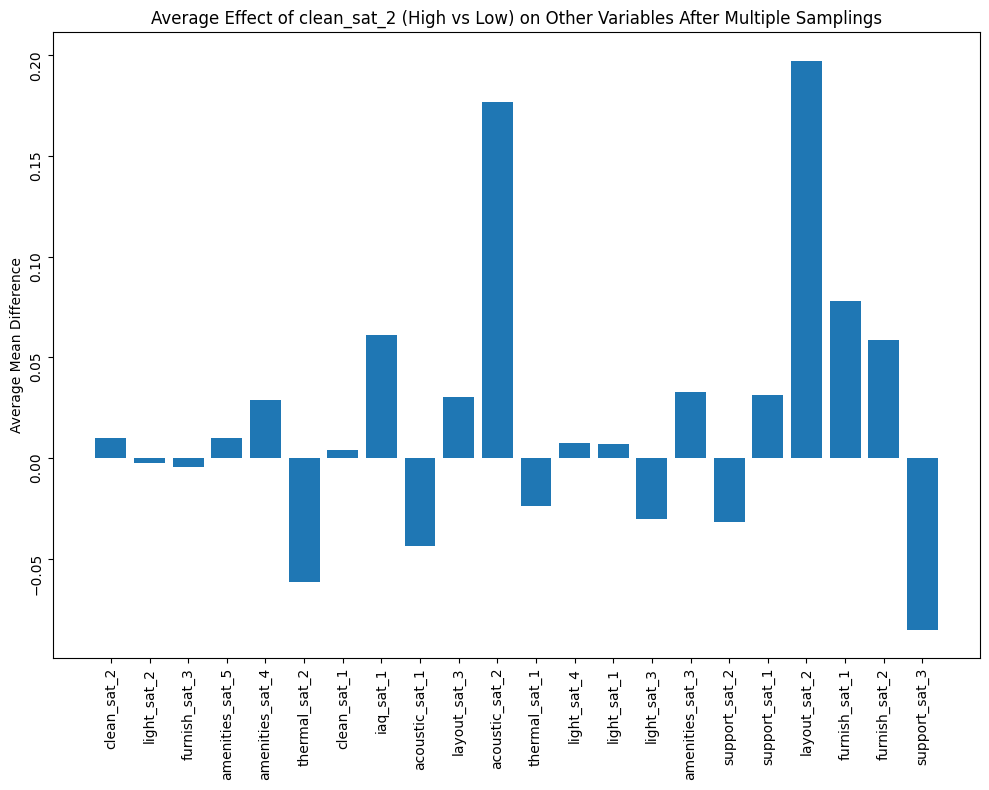

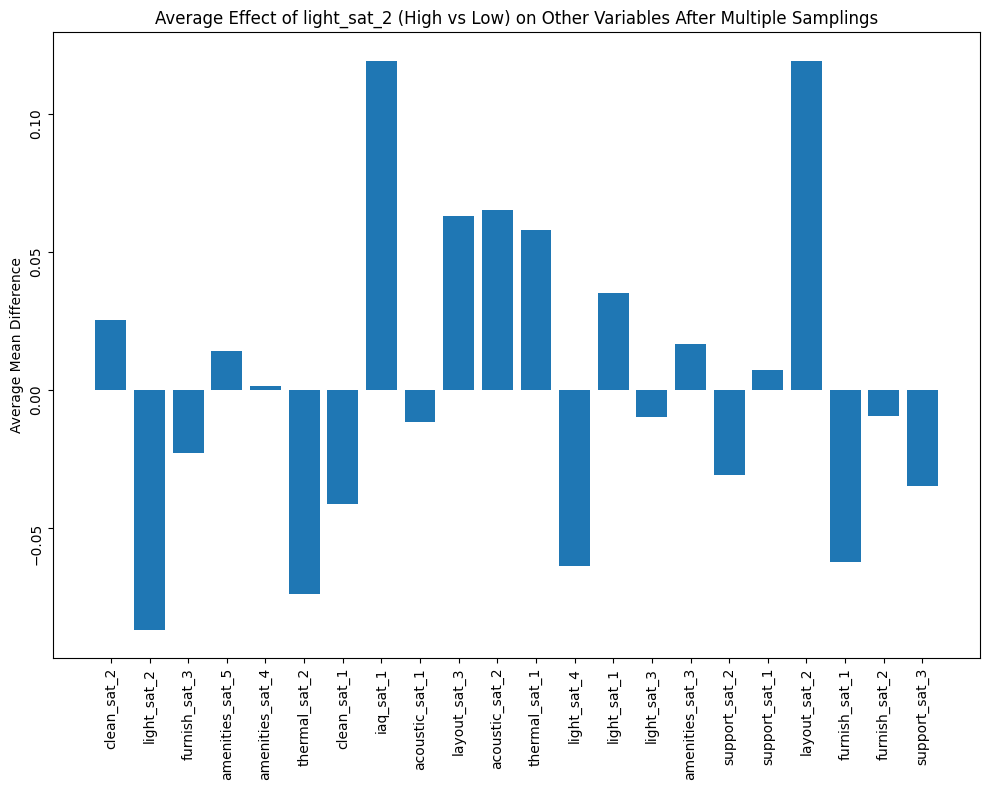

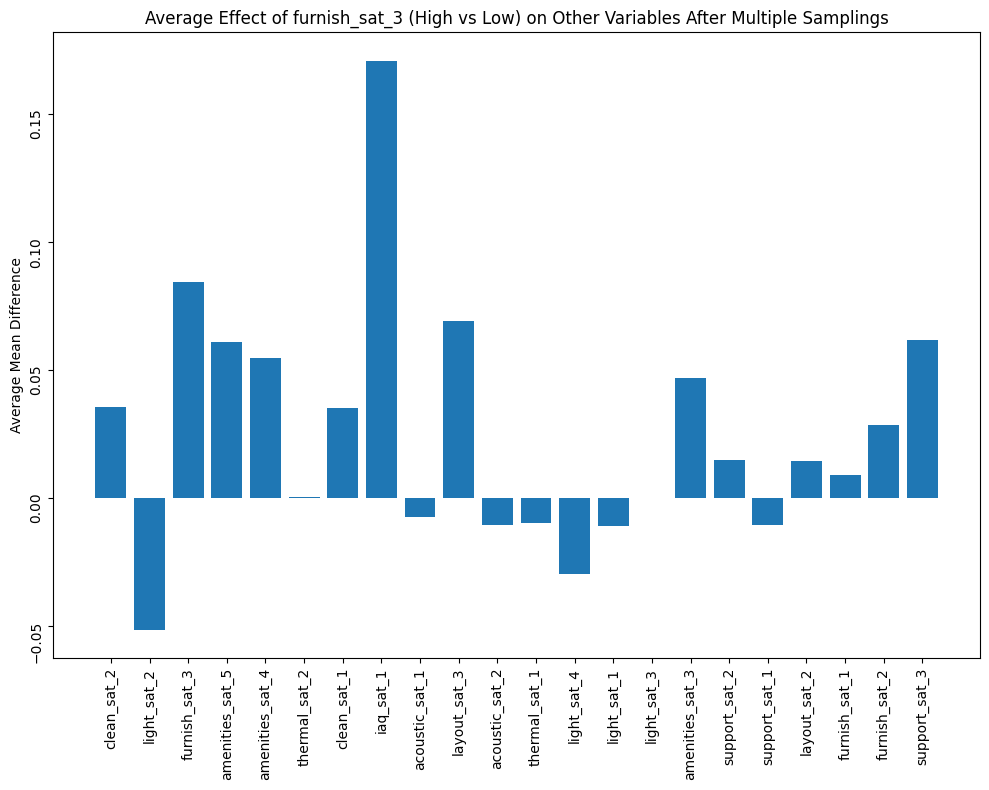

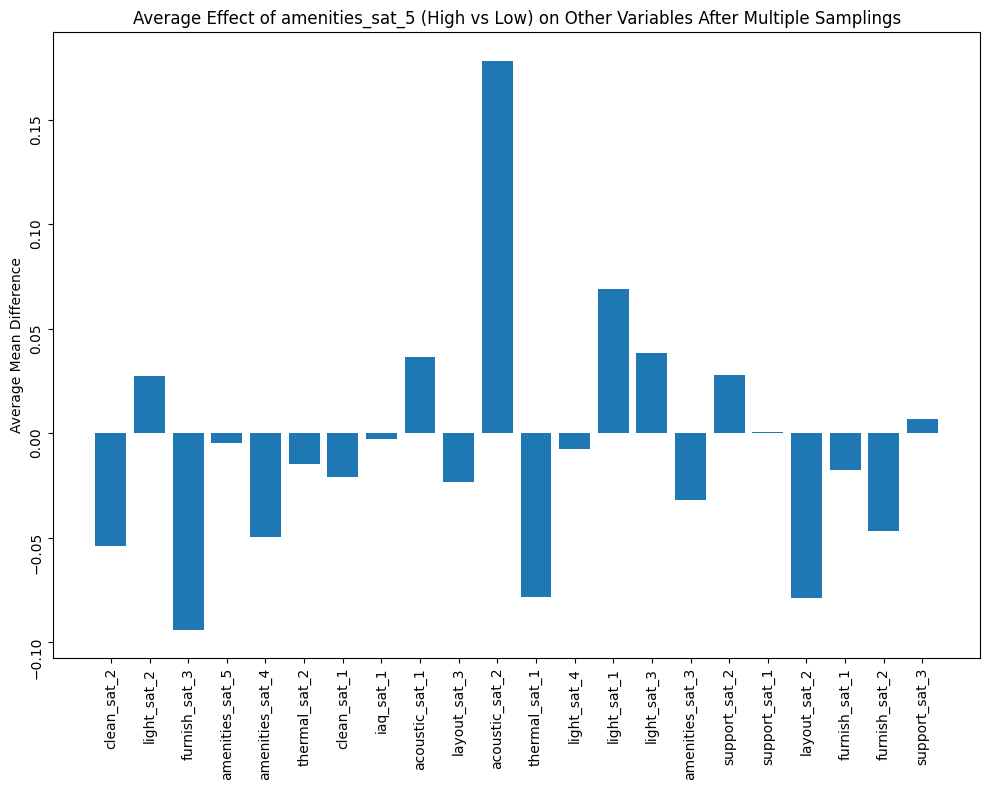

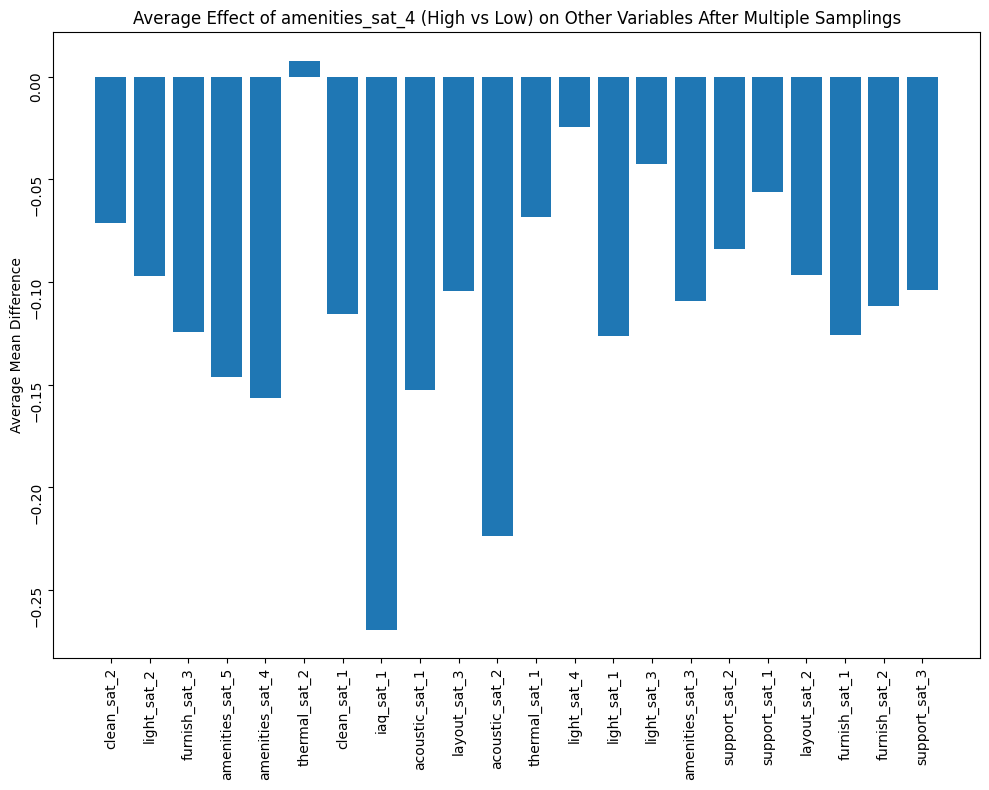

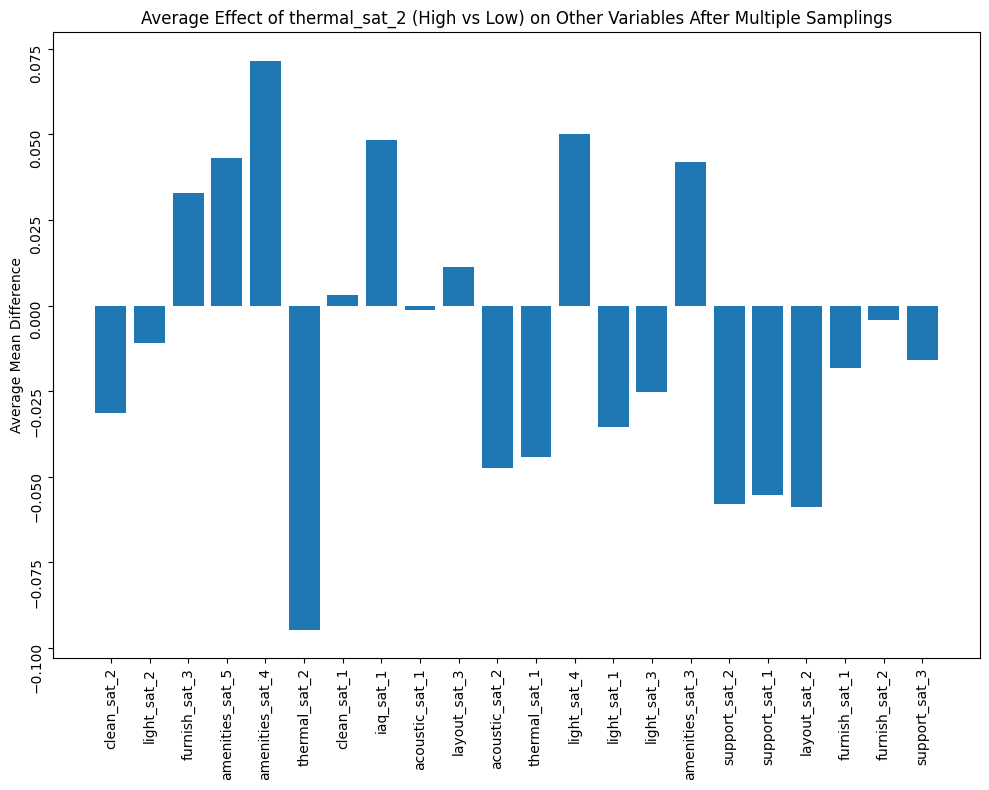

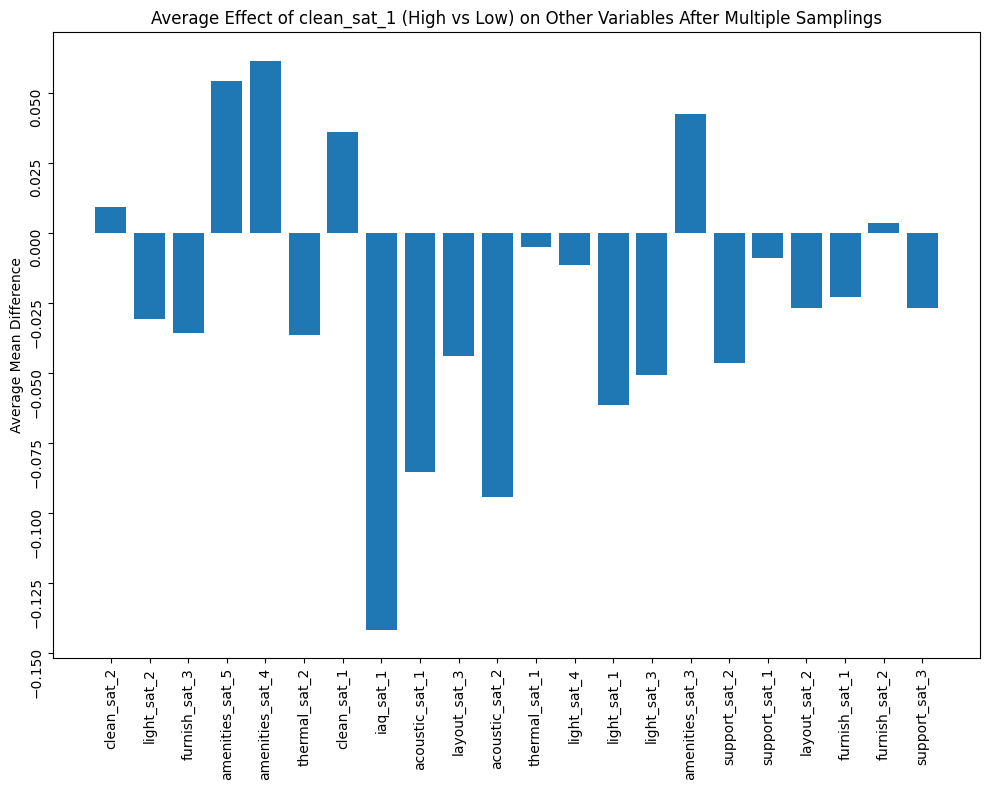

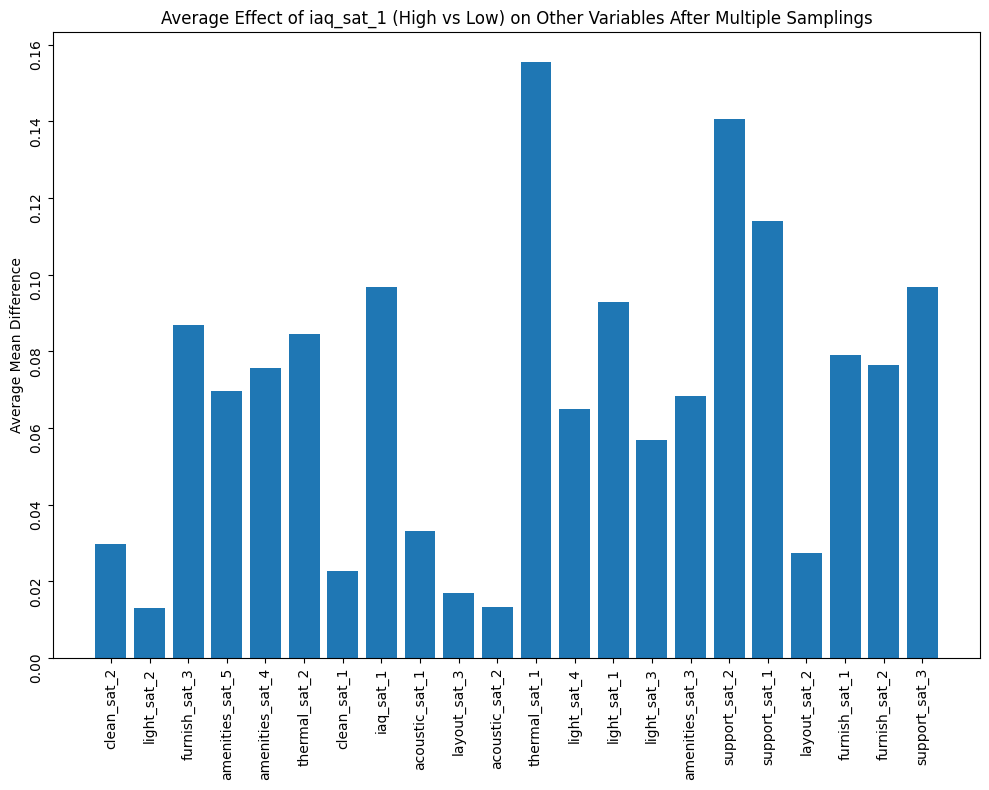

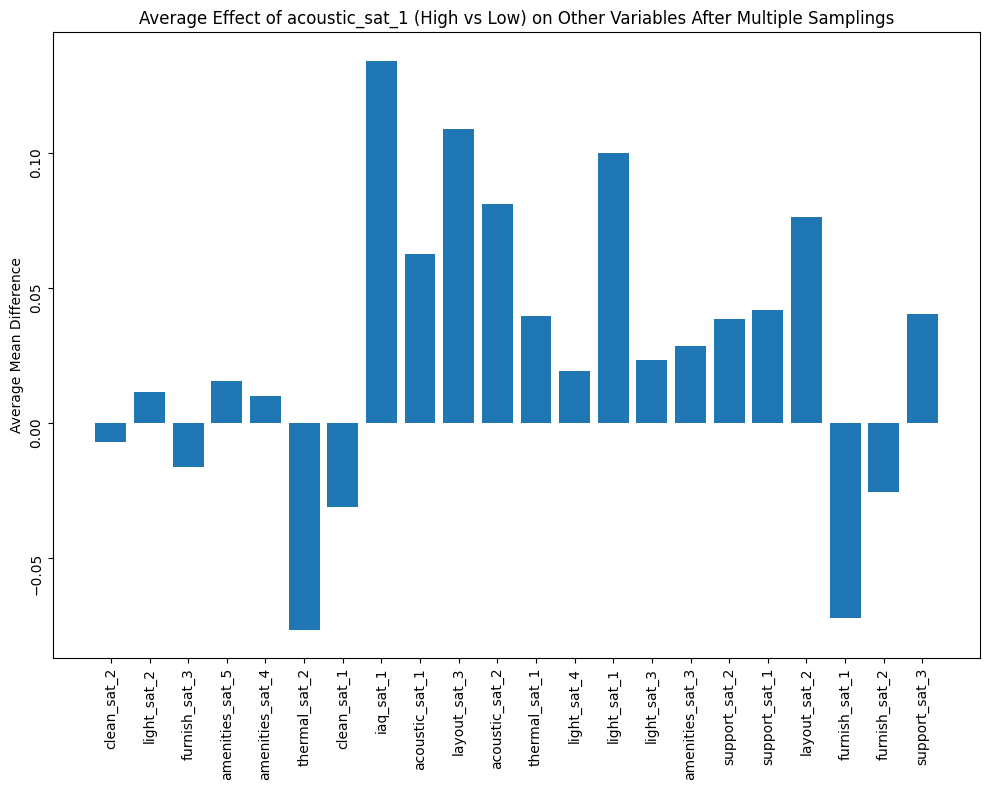

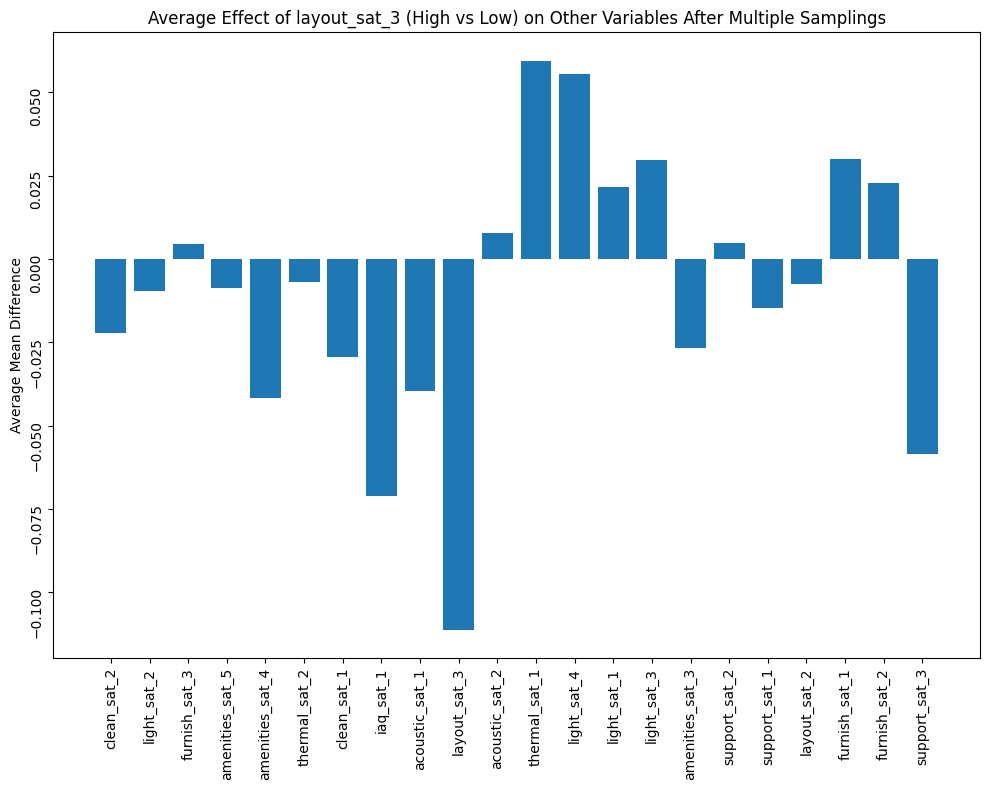

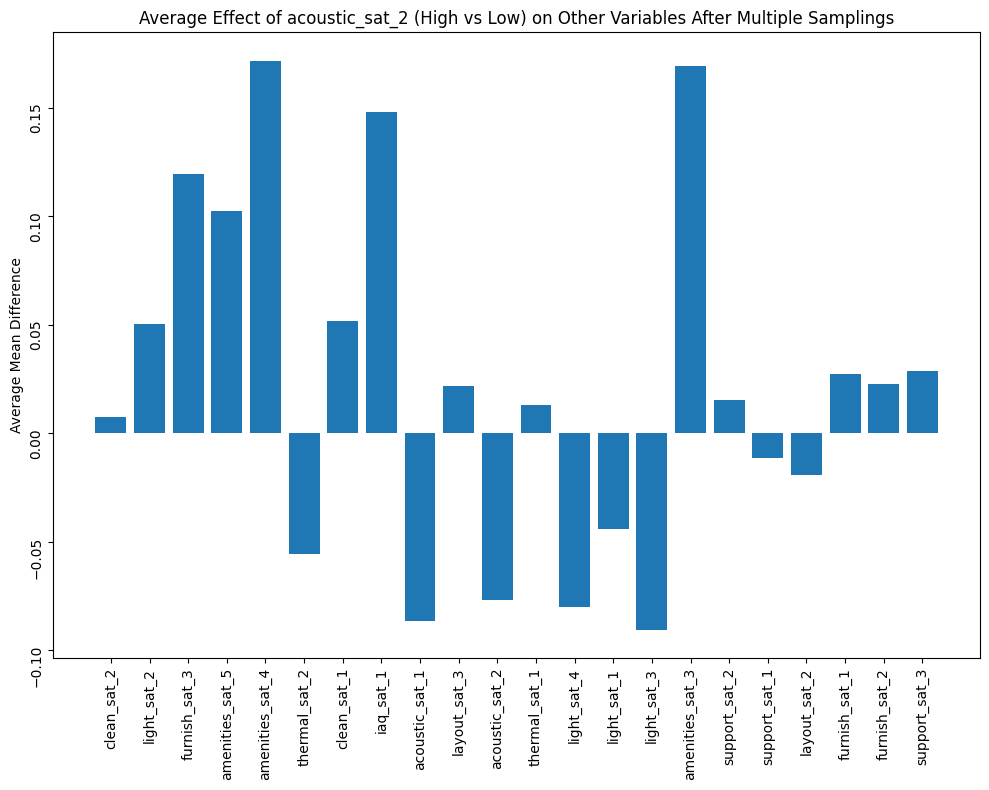

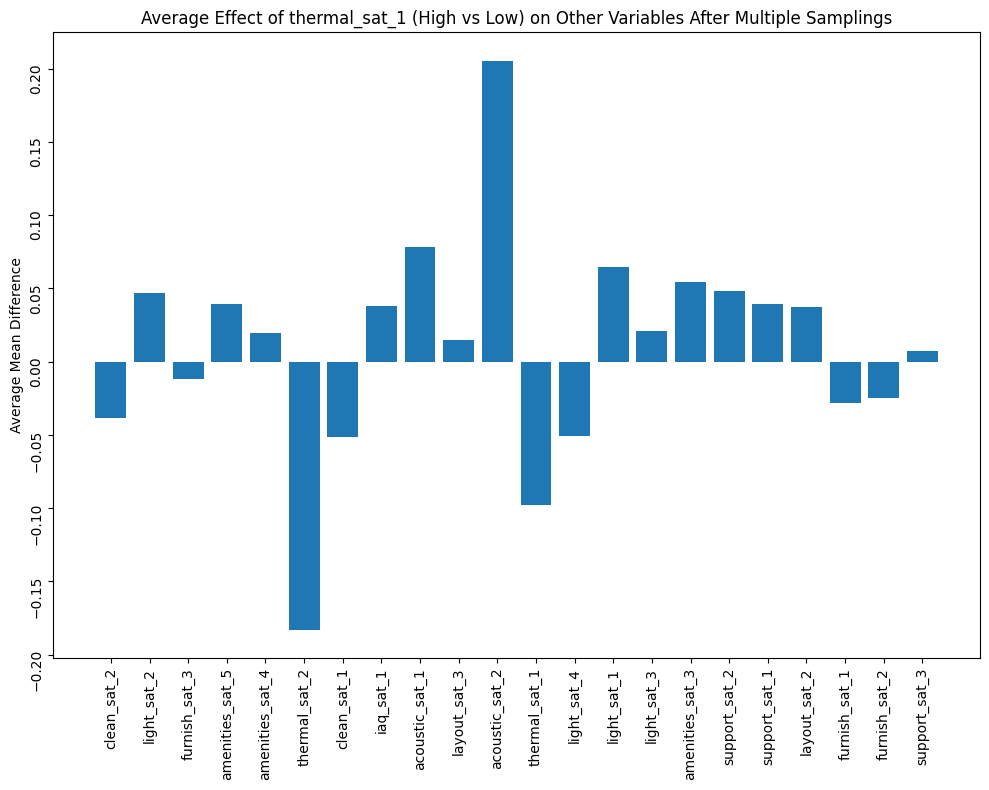

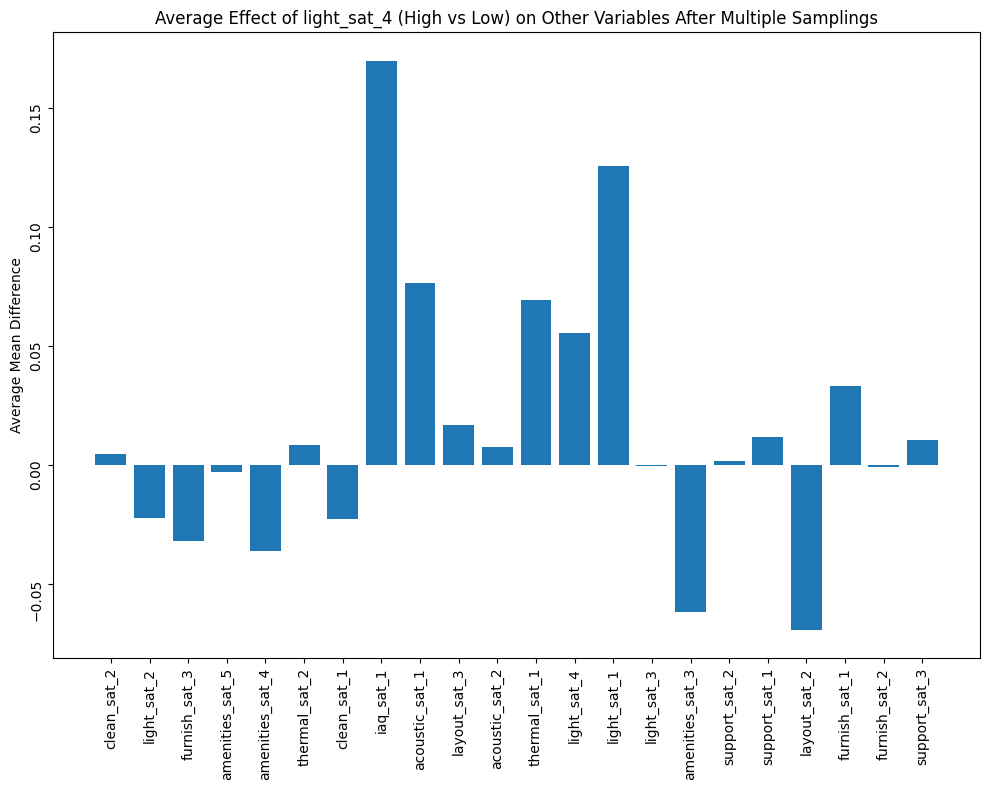

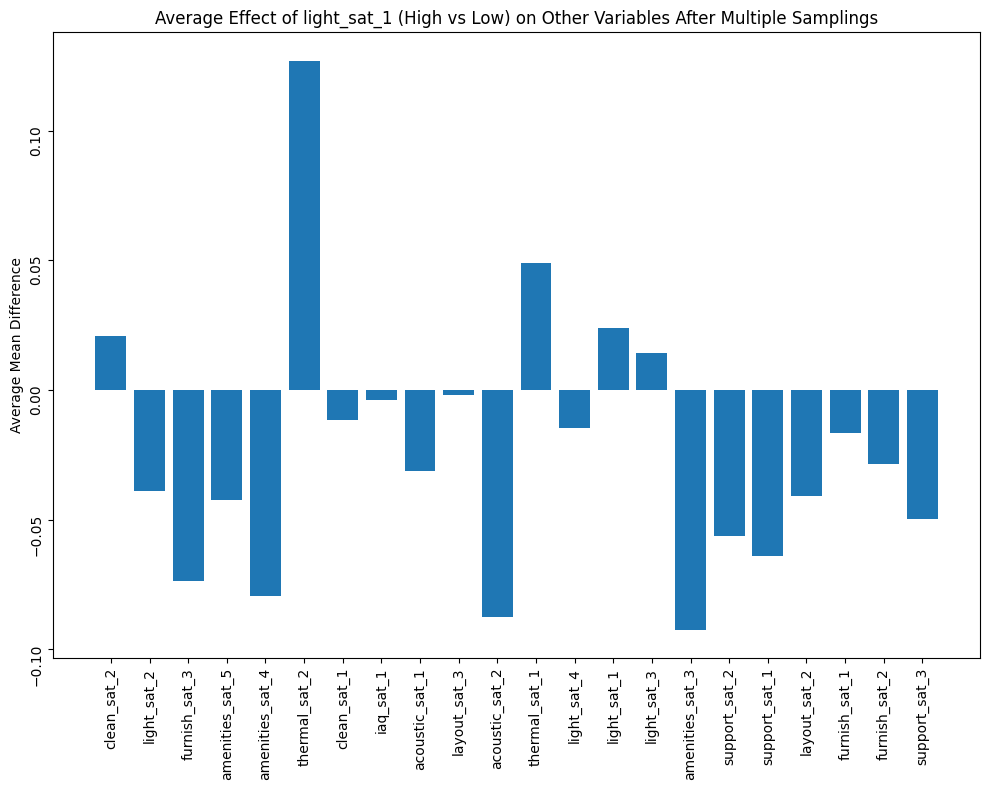

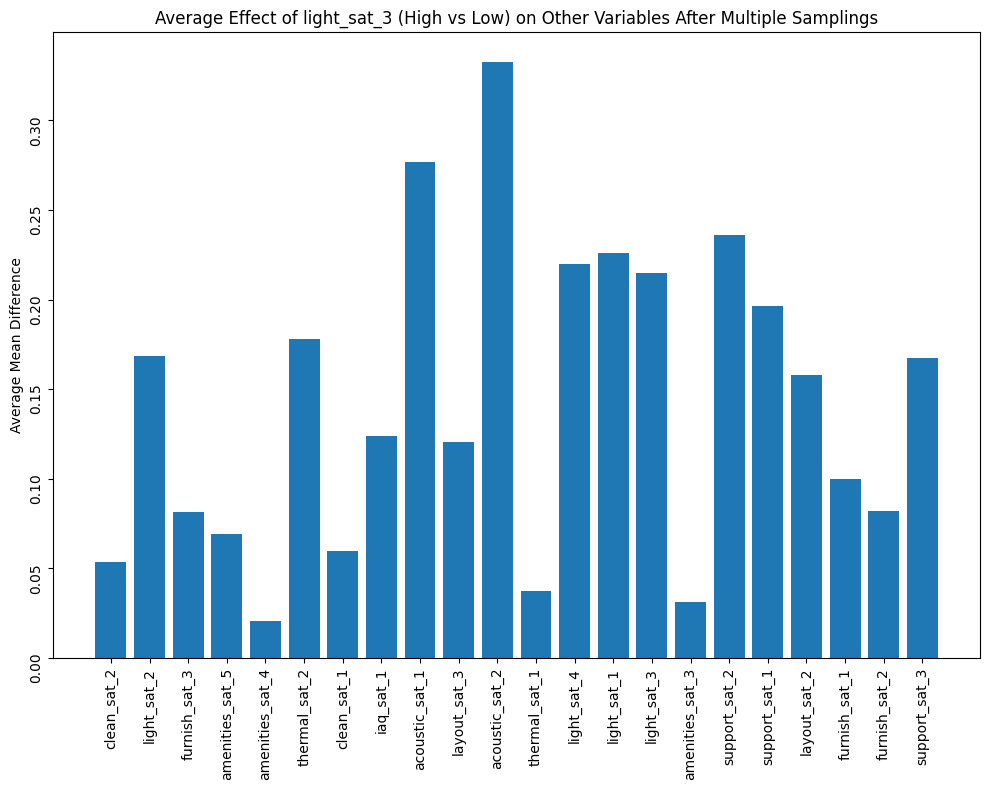

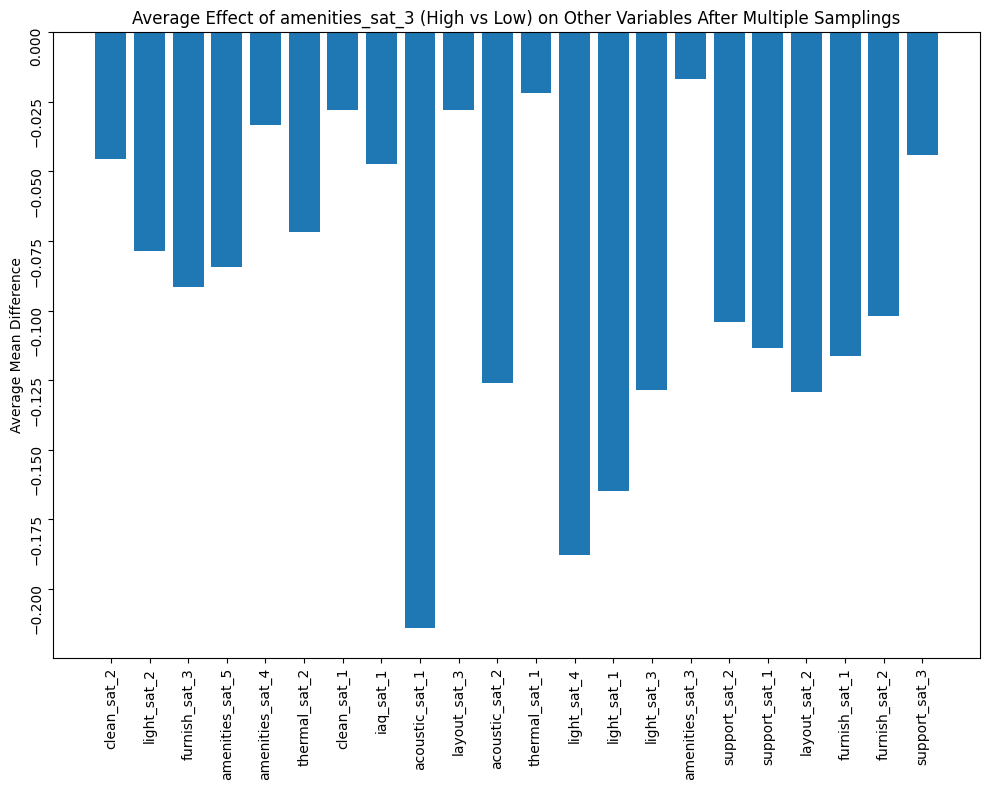

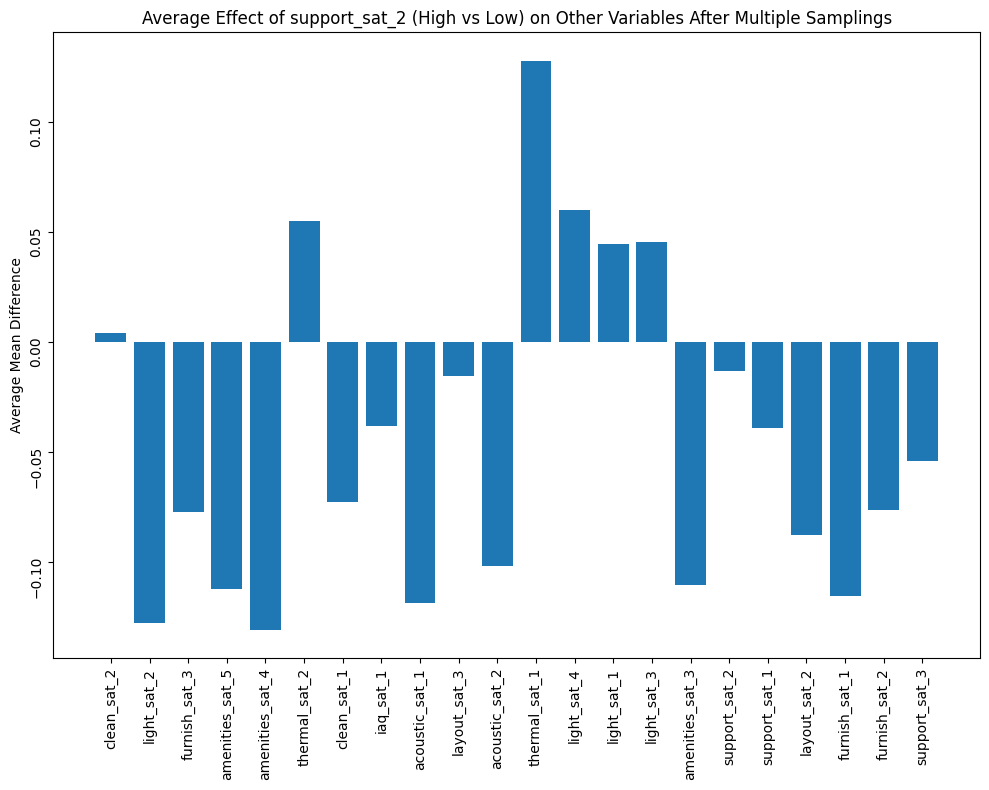

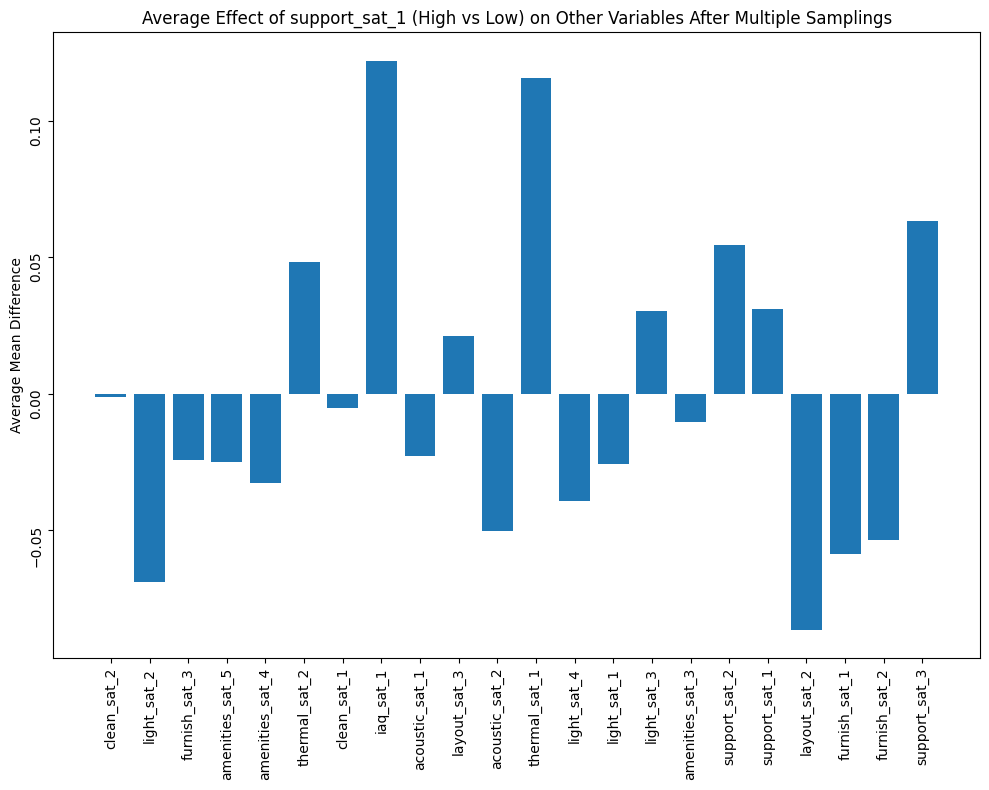

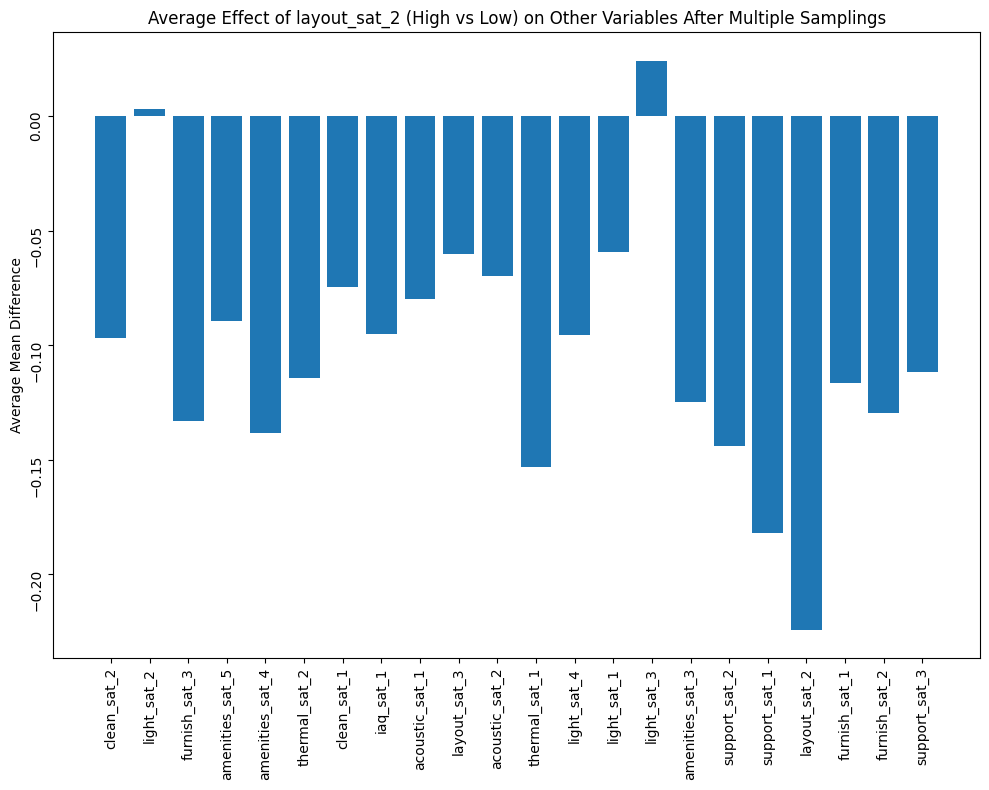

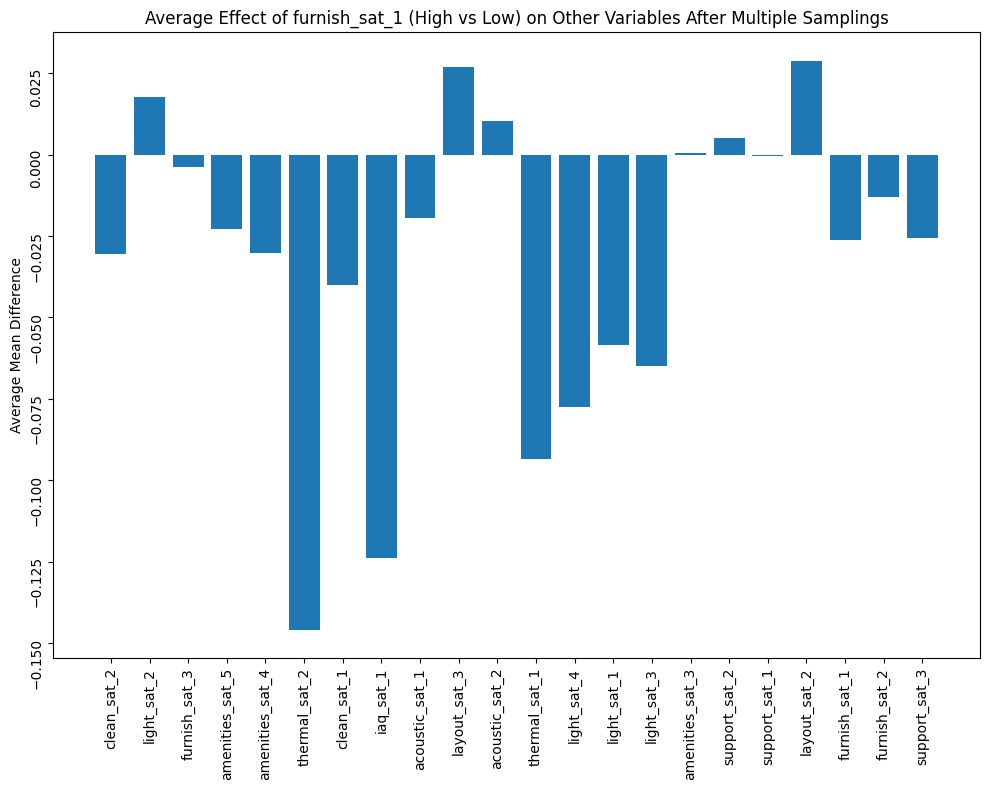

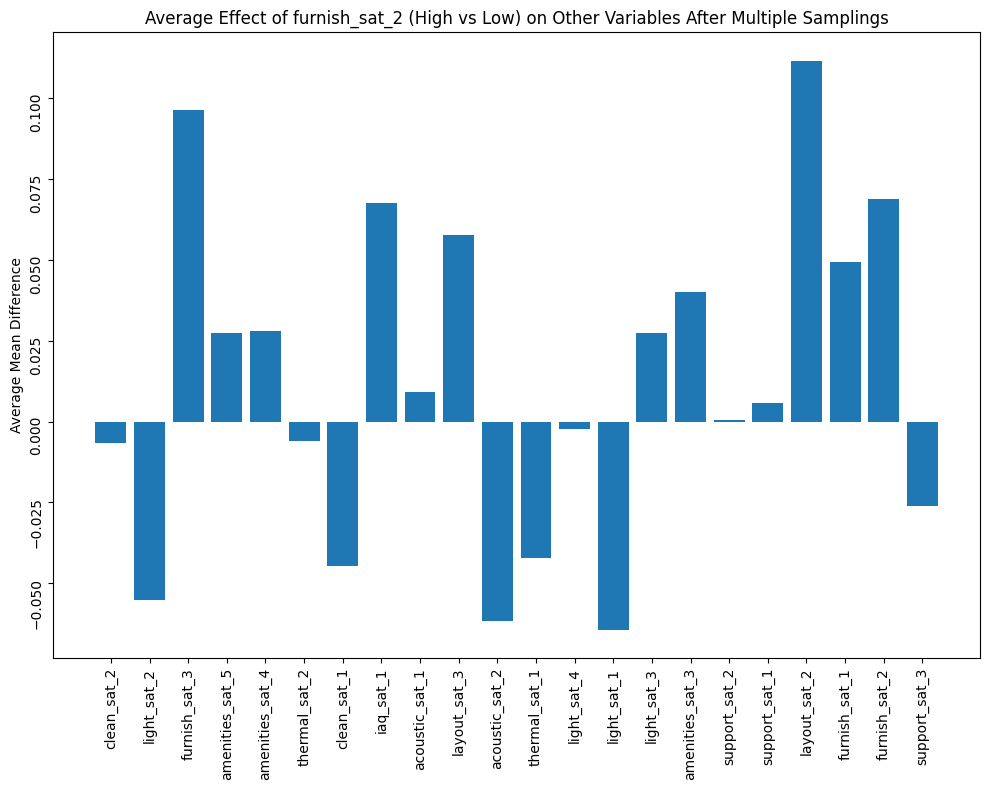

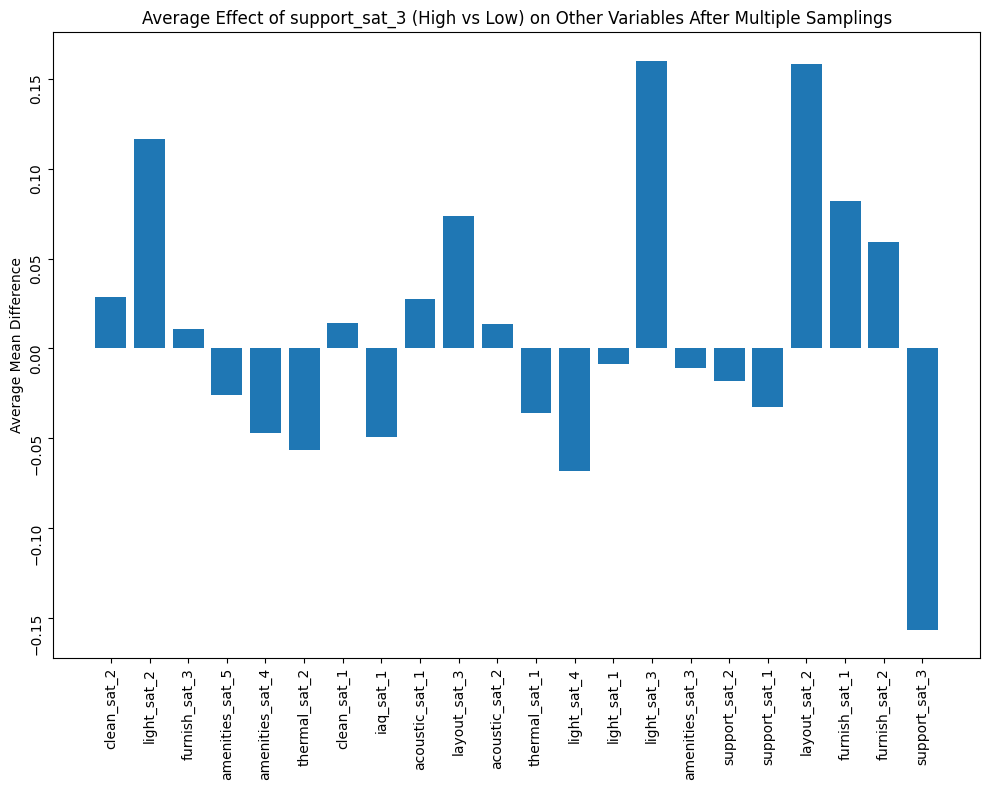

In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('validataion.csv')

sat_variables = [
    "clean_sat_2", "light_sat_2", "furnish_sat_3", "amenities_sat_5", "amenities_sat_4",
    "thermal_sat_2", "clean_sat_1", "iaq_sat_1", "acoustic_sat_1", "layout_sat_3",
    "acoustic_sat_2", "thermal_sat_1", "light_sat_4", "light_sat_1", "light_sat_3",
    "amenities_sat_3", "support_sat_2", "support_sat_1", "layout_sat_2", "furnish_sat_1",
    "furnish_sat_2", "support_sat_3"
]


def analyze_effects_through_sampling(dataframe, variables, n_samples=10):
    sample_results = {var: np.zeros(len(variables)) for var in variables}
    
    for var in variables:
        for _ in range(n_samples):
            dataframe[f'{var}_group'] = np.where(np.random.rand(len(dataframe)) < 0.5, 'High', 'Low')
            high_means = dataframe[dataframe[f'{var}_group'] == 'High'][variables].mean()
            low_means = dataframe[dataframe[f'{var}_group'] == 'Low'][variables].mean()
            
            mean_diff = high_means - low_means
            sample_results[var] += mean_diff

        sample_results[var] /= n_samples
    
    return sample_results


def analyze_effects_based_on_average(dataframe, variables, n_samples=10):
    sample_results = {var: np.zeros(len(variables)) for var in variables}
    
    for var in variables:
        mean_val = dataframe[var].mean()
        
        for _ in range(n_samples):
            dataframe[f'{var}_group'] = np.where(dataframe[var] >= mean_val, 'High', 'Low')
            high_means = dataframe[dataframe[f'{var}_group'] == 'High'][variables].mean()
            low_means = dataframe[dataframe[f'{var}_group'] == 'Low'][variables].mean()
            
            mean_diff = high_means - low_means
            sample_results[var] += mean_diff
        
        sample_results[var] /= n_samples
    
    return sample_results

results = analyze_effects_through_sampling(df, sat_variables, n_samples=50)

# for var in sat_variables:
for var in sat_variables:

    fig, ax = plt.subplots(figsize=(10, 8))
    ax.bar(range(len(sat_variables)), results[var], tick_label=sat_variables)
    ax.set_title(f'Average Effect of {var} (High vs Low) on Other Variables After Multiple Samplings')
    ax.set_ylabel('Average Mean Difference')
    ax.tick_params(labelrotation=90)
    plt.tight_layout()
    plt.show()